# Step-by-step TopoMetry analysis

In this tutorial we will apply the **step-by-step TopoMetry analysis workflow** to a single-cell dataset.  

We start by importing `scanpy`, `matplotlib`, and the TopoMetry single-cell helper functions from `topo.single_cell`.  

In [ ]:
# !pip install scanpy anndata matplotlib numpy scipy pandas
import scanpy as sc
import topo as tp

# figure settings
sc.settings.set_figure_params(dpi=100, facecolor='white', fontsize=14)

# suppress scanpy warnings (optional, but makes notebook cleaner)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

For this tutorial, we'll use scRNAseq data from the developing murine hypothalamus ([Huisman et al., Nat Comm, 2019](https://doi.org/10.1038/s41467-019-11667-y)). We download it from GSE126480 and place it in our current directory. 


## QC and preprocessing

In [ ]:
import scanpy as sc
import pandas as pd

# Read matrix
counts = pd.read_csv("Huisman_GSE126480/GSE126480_Raw_counts.txt", sep="\t", index_col=0)

# Construct AnnData
adata = sc.AnnData(counts.T)
adata.var_names = counts.index
adata.obs_names = counts.columns
adata

AnnData object with n_obs × n_vars = 6465 × 27998

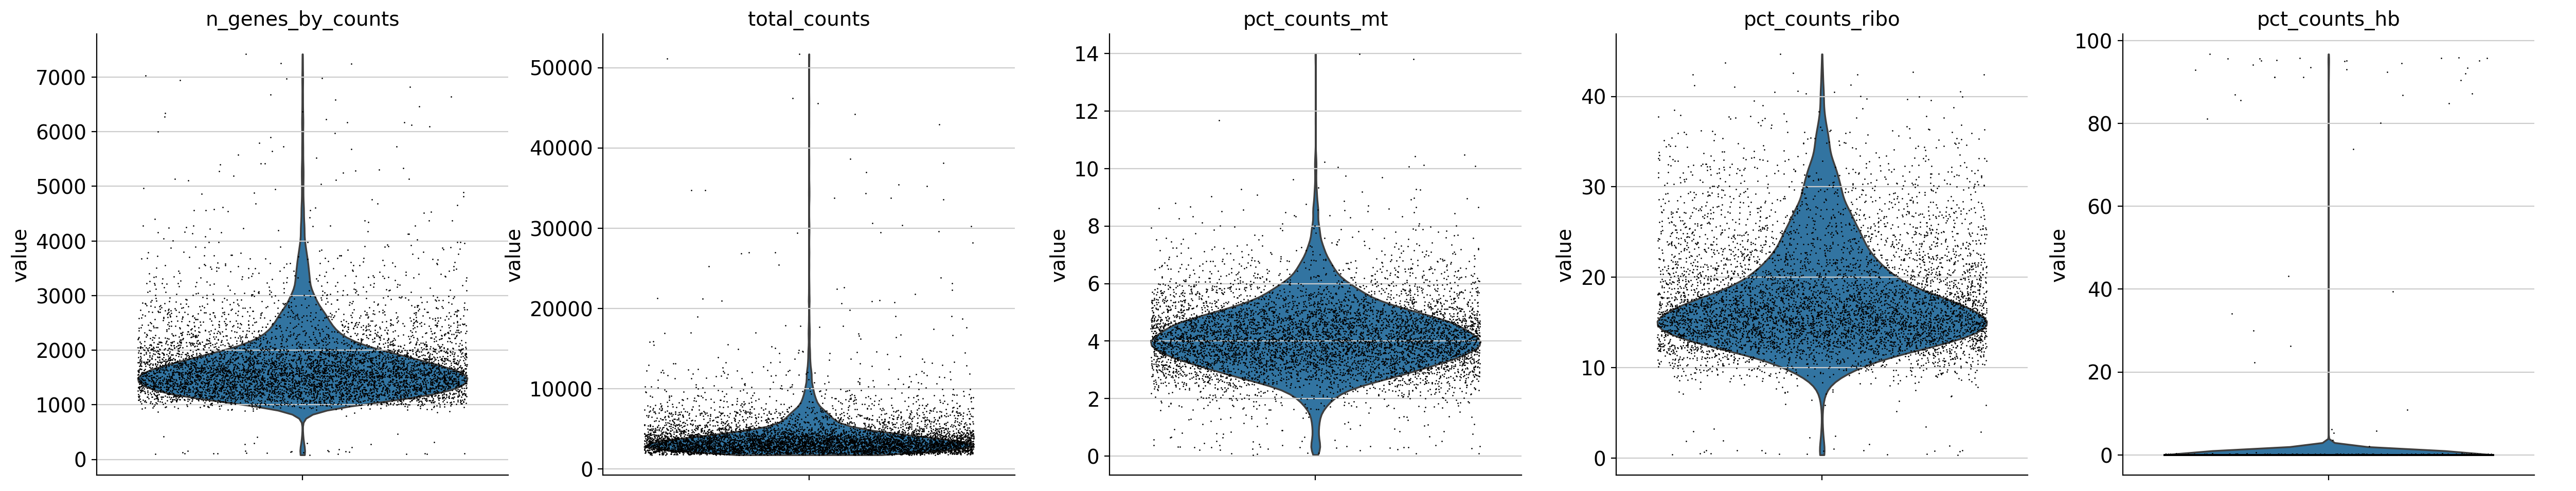

In [ ]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("mt-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^Hb[^(P)]")
# calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

# plot QC metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

and filter low-quality cells:

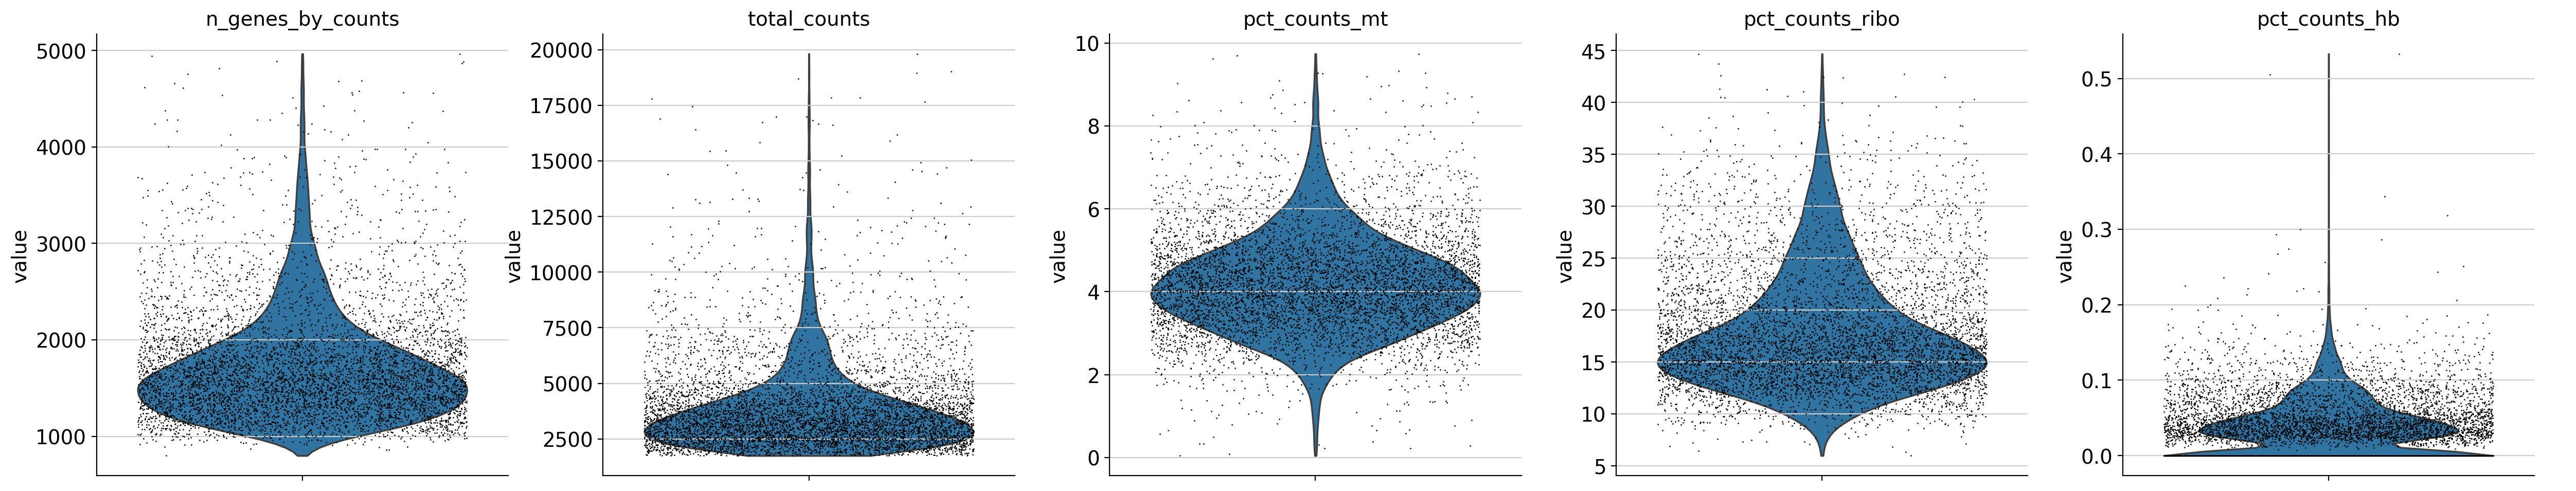

In [ ]:
# filter cells
adata = adata[
    (adata.obs.n_genes_by_counts > 500) & (adata.obs.n_genes_by_counts < 5000)
    & (adata.obs.total_counts < 20000)  & (adata.obs.total_counts > 500)
    & (adata.obs.pct_counts_mt < 10)
    & (adata.obs.pct_counts_hb < 1),
    :,
].copy()

# plot filtered QC metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)


Before we proceed with our `topometry` analysis, we need to make sure our `AnnData` object has been normalized appropriately:

In [ ]:
adata = tp.sc.preprocess(adata)

## Fitting TopoMetry on `AnnData` (using `tp.sc.fit_adata`)

We begin with the core analysis call: `tp.sc.fit_adata(adata)`. This function:

1) **Fits a `TopOGraph`** on the scaled HVG matrix in `adata.X` (builds the base kNN graph and diffusion operator).  
2) **Computes both spectral scaffolds** — **multiscale diffusion (msDM)** and **fixed-time diffusion (DM)** — and stores them in `adata.obsm` as `X_ms_spectral_scaffold` and `X_spectral_scaffold`.  
3) **Sizes the scaffolds automatically** using intrinsic dimensionality estimates gathered during fitting.  
4) **Constructs refined graph operators** on each scaffold for downstream layouts.  
5) **Generates 2-D embeddings** (e.g. **TopoMAP**, **TopoPaCMAP**) and writes them into `adata.obsm` (e.g. `X_msMAP`, `X_MAP`, `X_msPaCMAP`, `X_PaCMAP`).  
6) *(Optional)* **Runs Leiden clustering** over the refined TopoMetry graph and writes labels to `adata.obs` (e.g. `topo_clusters`, plus per-resolution columns).  

The function **returns the fitted `TopOGraph` object (`tg`)** and **modifies `adata` in-place**, so you can immediately explore scaffolds, layouts, and clusters in your Scanpy workflow.

Additional keyword arguments to 


In [ ]:
# Core analysis (tweak hyperparams as desired)
tg = tp.sc.fit_adata(
    adata, 
    projections=("MAP", "PaCMAP"), # projections to compute with topometry
    do_leiden=True, # whether to compute leiden clusters with topometry
    leiden_key_base="topo_clusters", # base name for leiden clusters
    leiden_resolutions=(0.2, 0.8, 1.2), # resolutions for leiden clustering
    # additional kwargs are passed to tp.TopOGraph:
    n_jobs=-1 # use all available CPU cores (topometry is highly parallelizable)
)


Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!
Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!


This populates our `AnnData` object with topometry results:

In [ ]:
adata

AnnData object with n_obs × n_vars = 6368 × 3000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'topo_clusters_res0.2', 'topo_clusters_res0.8', 'topo_clusters_res1.2', 'topo_clusters'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', '_topo_tmp', 'topo_clusters_res0.2', 'topo_clusters_res0.8', 'topo_clusters_res1.2'
    obsm: 'X_ms_spectral_scaffold', 'X_spectral_scaffold', 'X_msTopoMAP', 'X_TopoMAP', 'X_msTo

## Inspecting the eigenspectrum

The eigenspectrum (scree plot) shows the decay of diffusion eigenvalues.  
In contrast to PCA, where eigenvalues often drop sharply, **diffusion eigenvalues typically decay gently**, meaning that meaningful information is spread across many components.  

This justifies TopoMetry’s design: **large spectral scaffolds** (dozens or even hundreds of components) are often required to capture the dataset’s latent geometry.  

We can inspect our eigenspectrum with:


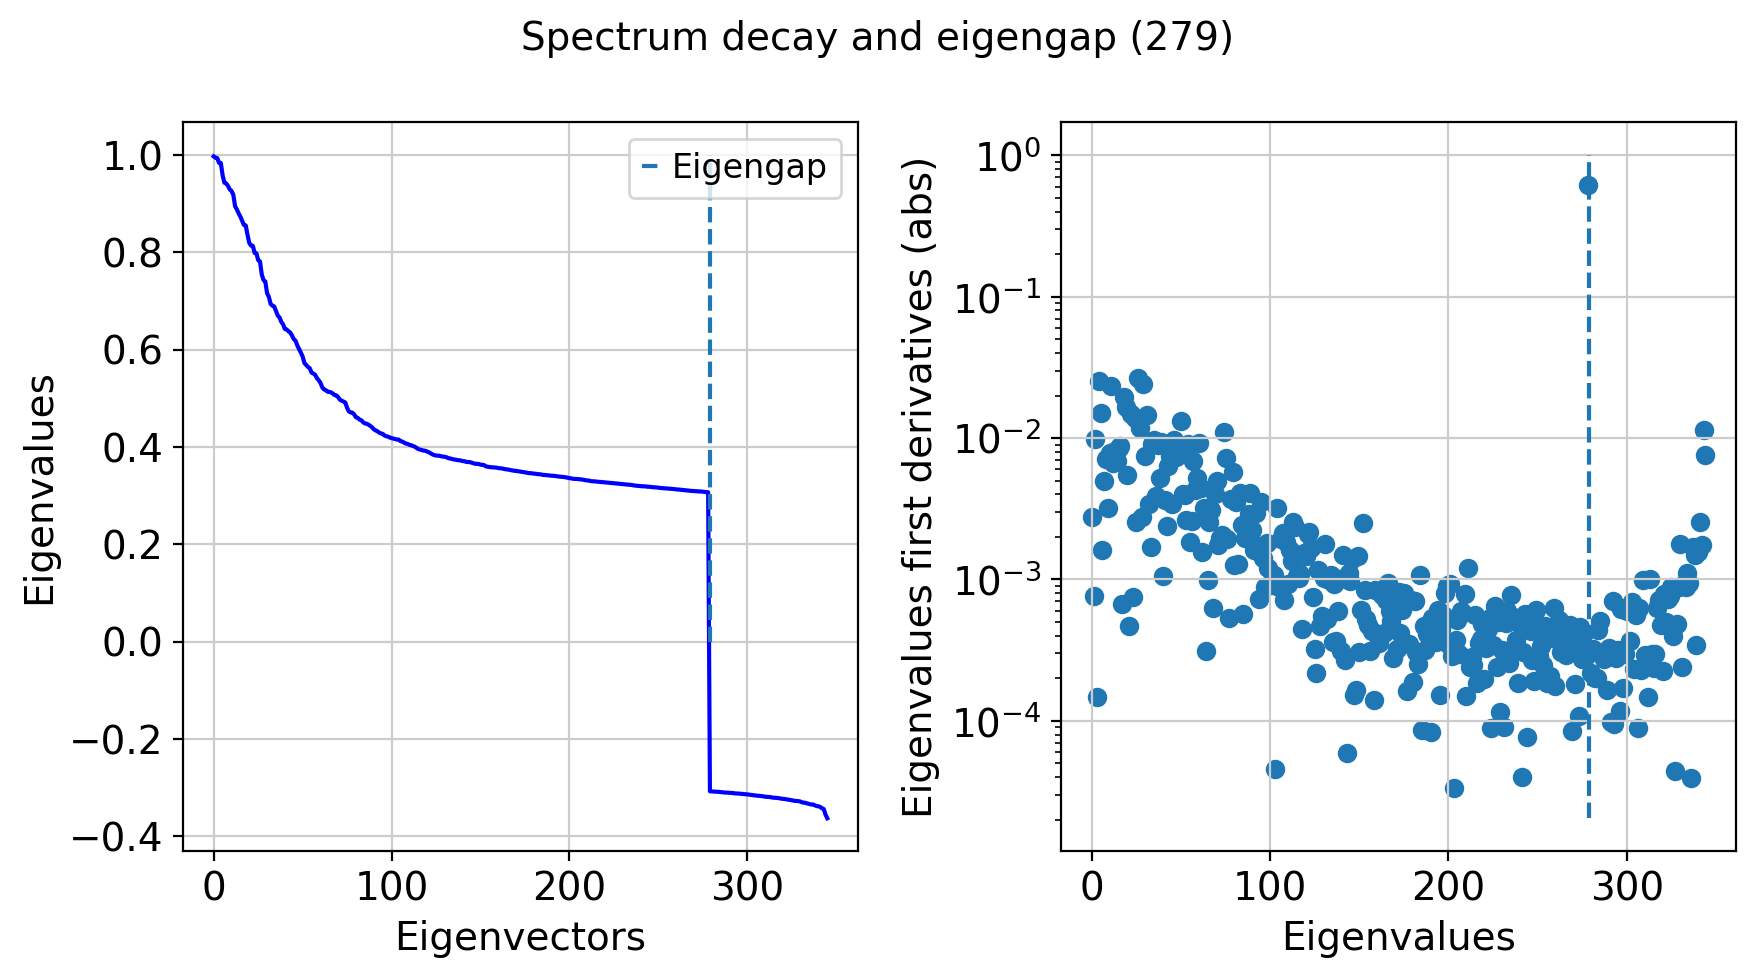

In [ ]:
tg.eigenspectrum()

A sharp eigengap in the scree plot (such as above) means that we computed components up to computational precision (i.e. 64 bits), at which point the eigendecomposition backend libraries (e.g. ARPACK) start outputting negative values. That's the ideal-case scenario: we want to encode our data with as many components as possible to make sure we're capturing all of the original geometry.

## Inspecting representations

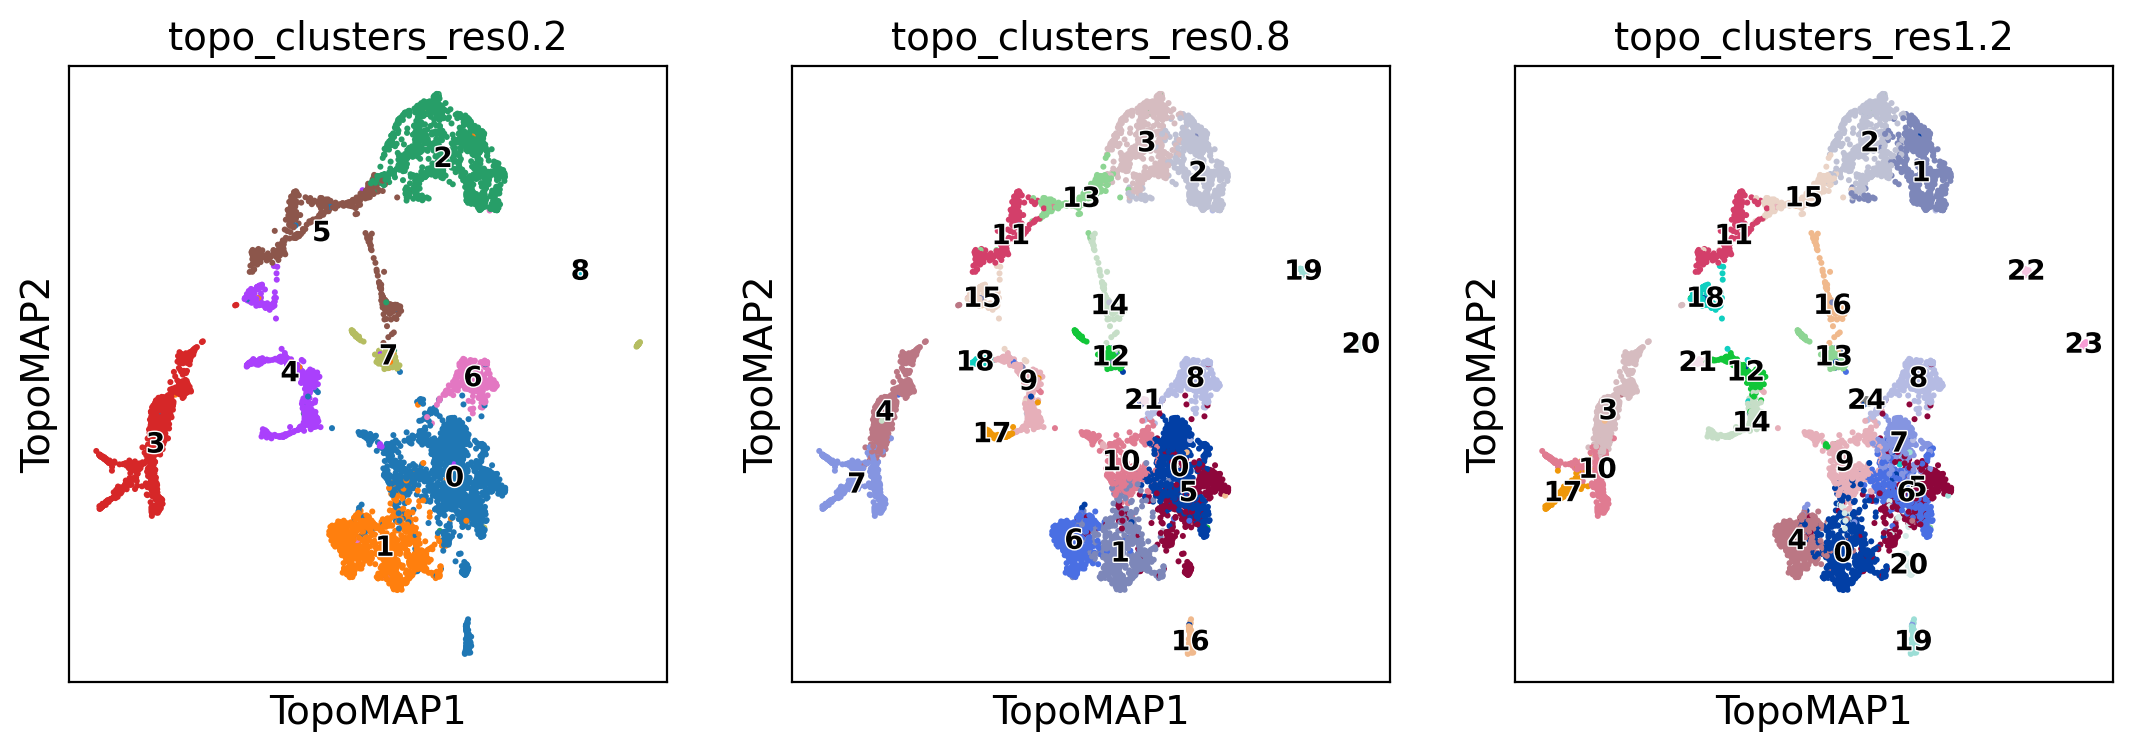

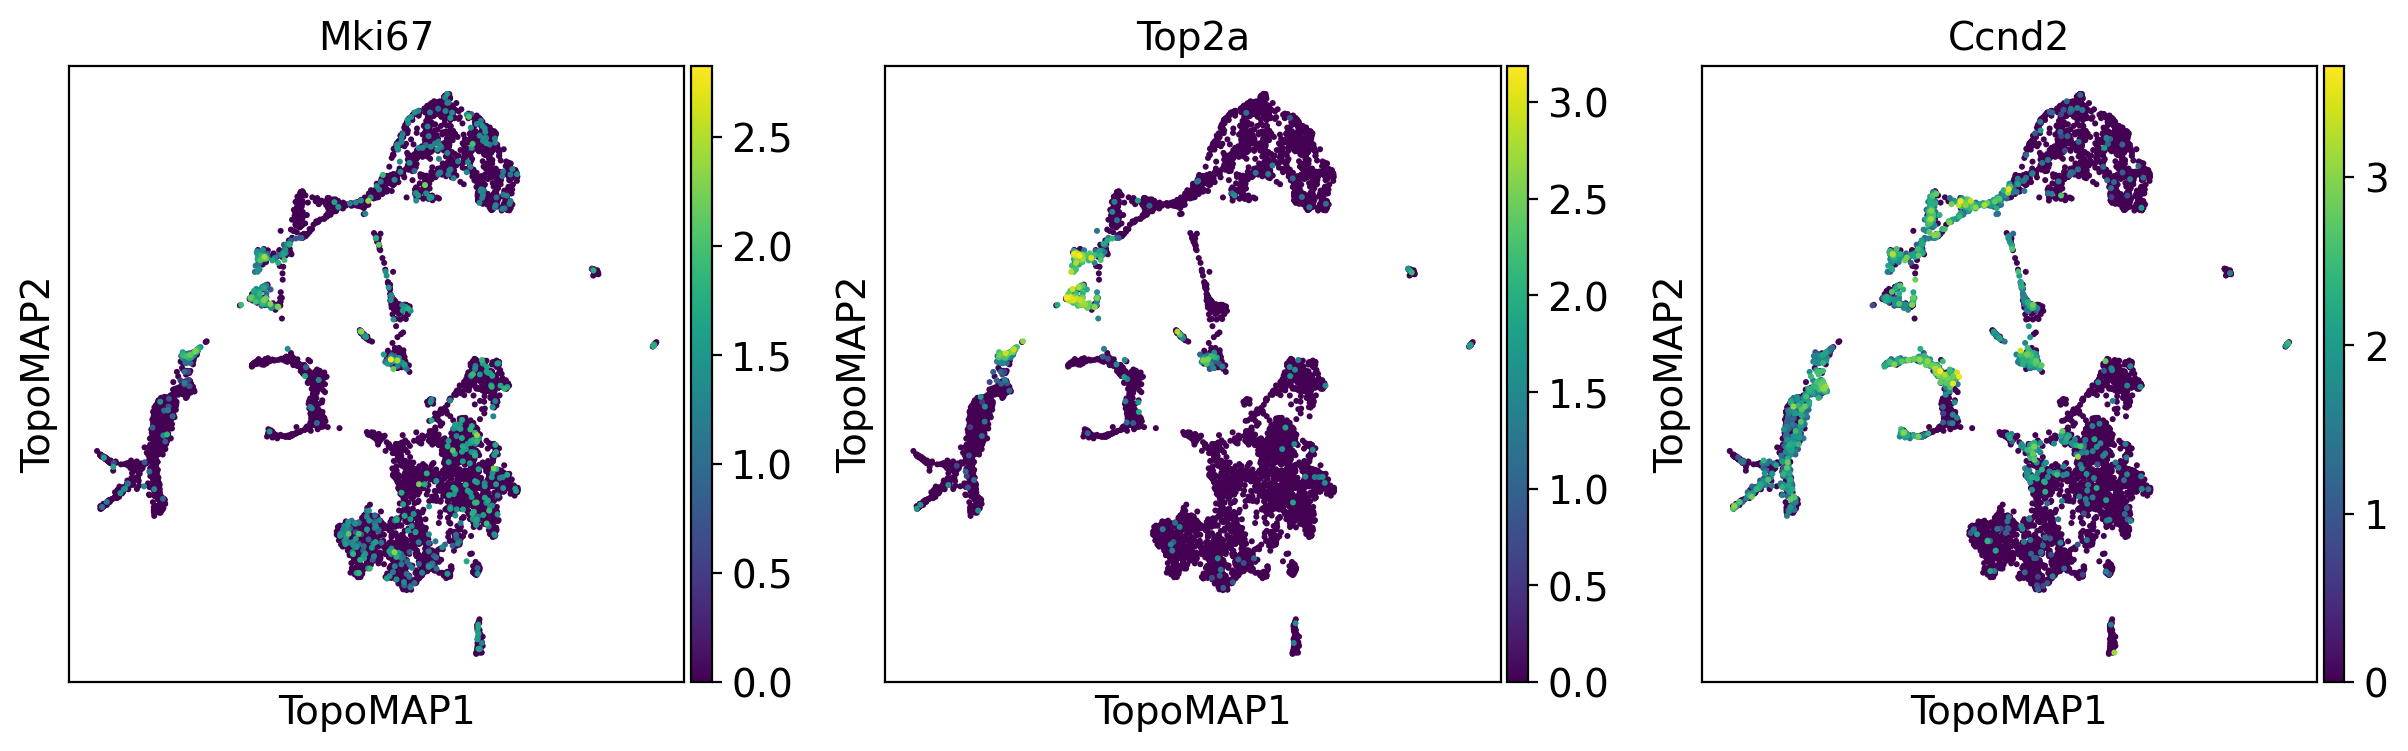

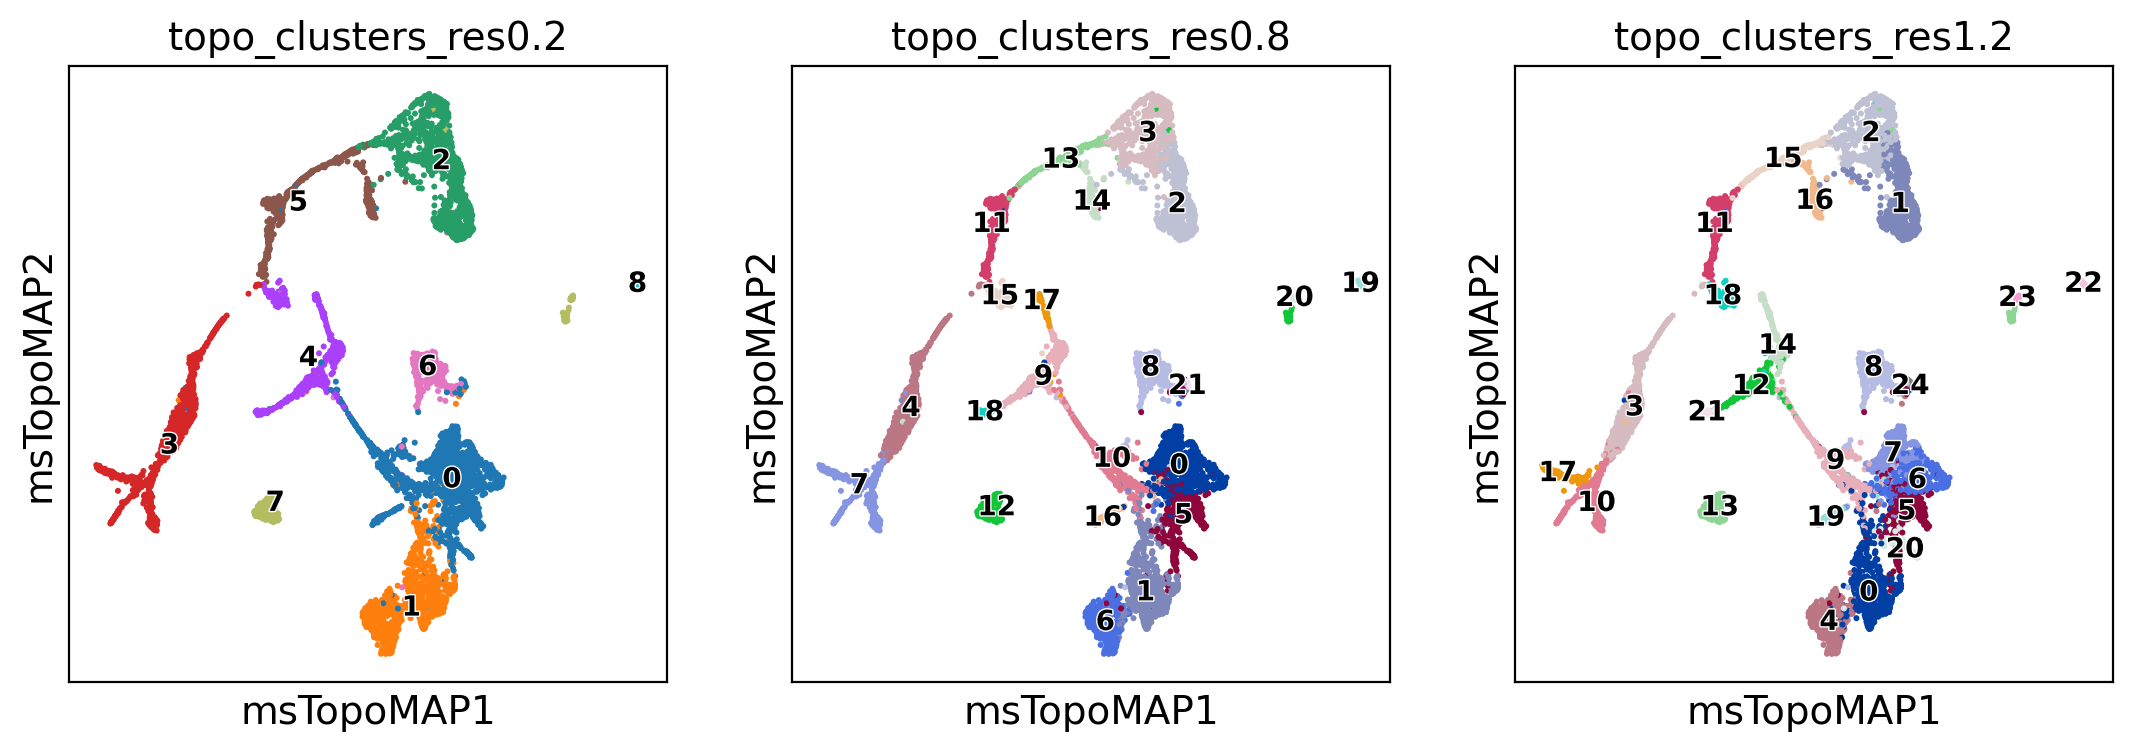

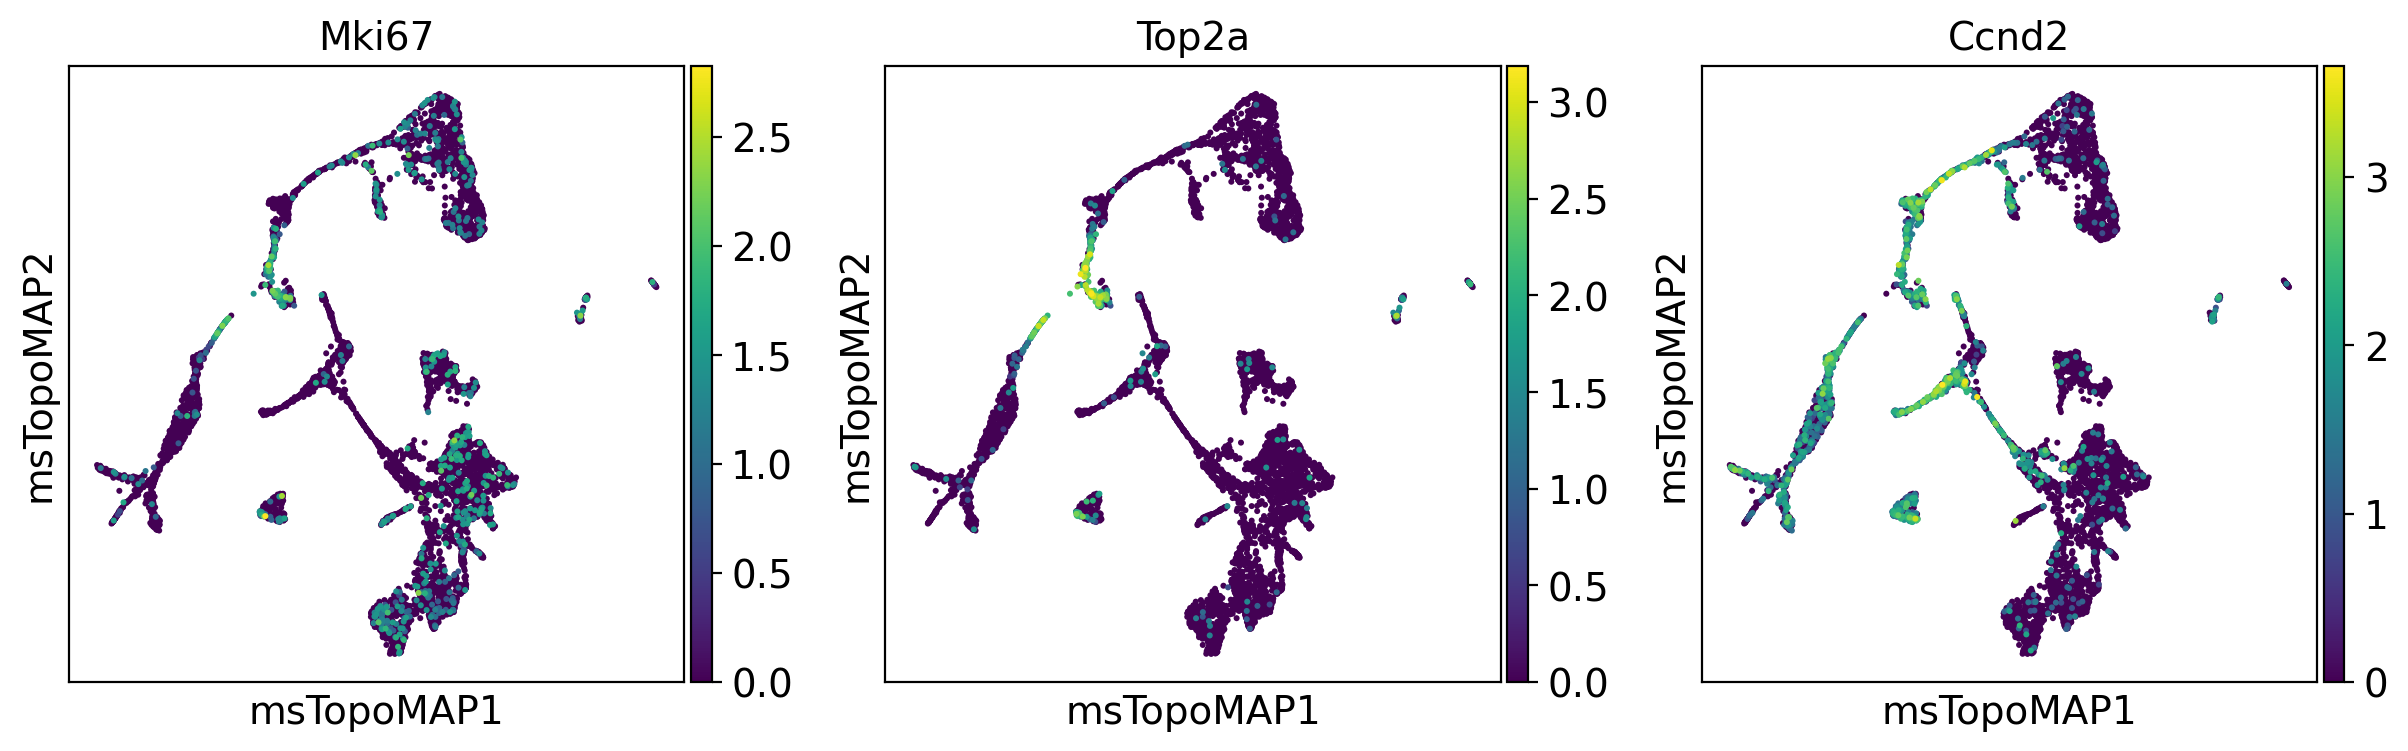

In [ ]:
sc.pl.embedding(adata, basis="TopoMAP", color=['topo_clusters_res0.2', 'topo_clusters_res0.8', 'topo_clusters_res1.2'], legend_loc='on data', legend_fontsize=10, legend_fontoutline=1, wspace=0.1)
sc.pl.embedding(adata, basis="TopoMAP", color=['Mki67', 'Top2a', 'Ccnd2'])

sc.pl.embedding(adata, basis="msTopoMAP", color=['topo_clusters_res0.2', 'topo_clusters_res0.8', 'topo_clusters_res1.2'], legend_loc='on data', legend_fontsize=10, legend_fontoutline=1, wspace=0.1)
sc.pl.embedding(adata, basis="msTopoMAP", color=['Mki67', 'Top2a', 'Ccnd2'])


## Comparison with the standard PCA→UMAP workflow

To benchmark, we run a **traditional PCA + UMAP + Leiden** workflow.  
We then compare cluster assignments with the TopoMetry-derived clusters.  

This comparison highlights how geometry-aware embeddings can lead to **different cluster boundaries** and often reveal **subtler structures** that PCA-UMAP may overlook.  

We also compute an Adjusted Rand Index (ARI) to quantify overlap between clusterings.  


In [ ]:
# Standard PCA→neighbors→UMAP + Leiden for comparison
sc.tl.pca(adata, use_highly_variable=False)
sc.pp.neighbors(adata, n_pcs=40, metric="cosine", key_added="pca")
sc.tl.umap(adata, neighbors_key="pca")
sc.tl.leiden(adata, neighbors_key="pca", key_added="leiden_pca", resolution=1.0)

# Contingency + simple ARI
from sklearn.metrics import adjusted_rand_score
comp_table = pd.crosstab(adata.obs["topo_clusters"], adata.obs["leiden_pca"])
ari = adjusted_rand_score(adata.obs["topo_clusters"], adata.obs["leiden_pca"])
display(comp_table)
print(f"ARI(topometry vs PCA-Leiden) = {ari:.3f}")

# Quick UMAP plots
sc.pl.embedding(adata, color=["topo_clusters","leiden_pca"], wspace=0.3, show=True)


## Intrinsic dimensionality histograms

TopoMetry estimates intrinsic dimensionality (ID) both **globally** and **locally** using two different algorithms: [MLE](https://www.stat.berkeley.edu/~bickel/mldim.pdf) and [FSA](https://doi.org/10.7717/peerj-cs.790).  

- **Global estimates (MLE, FSA):** dataset-wide proxies for effective degrees of freedom.  
- **Local IDs (FSA):** per-cell values that quantify the geometric complexity of each neighbourhood.  

Histograms of local IDs help identify trends ID estimates across resolutions (i.e. across different numbers of k-nearest-neighbors). They also allow us to visualize how these ID estimates are distributed across different cells.



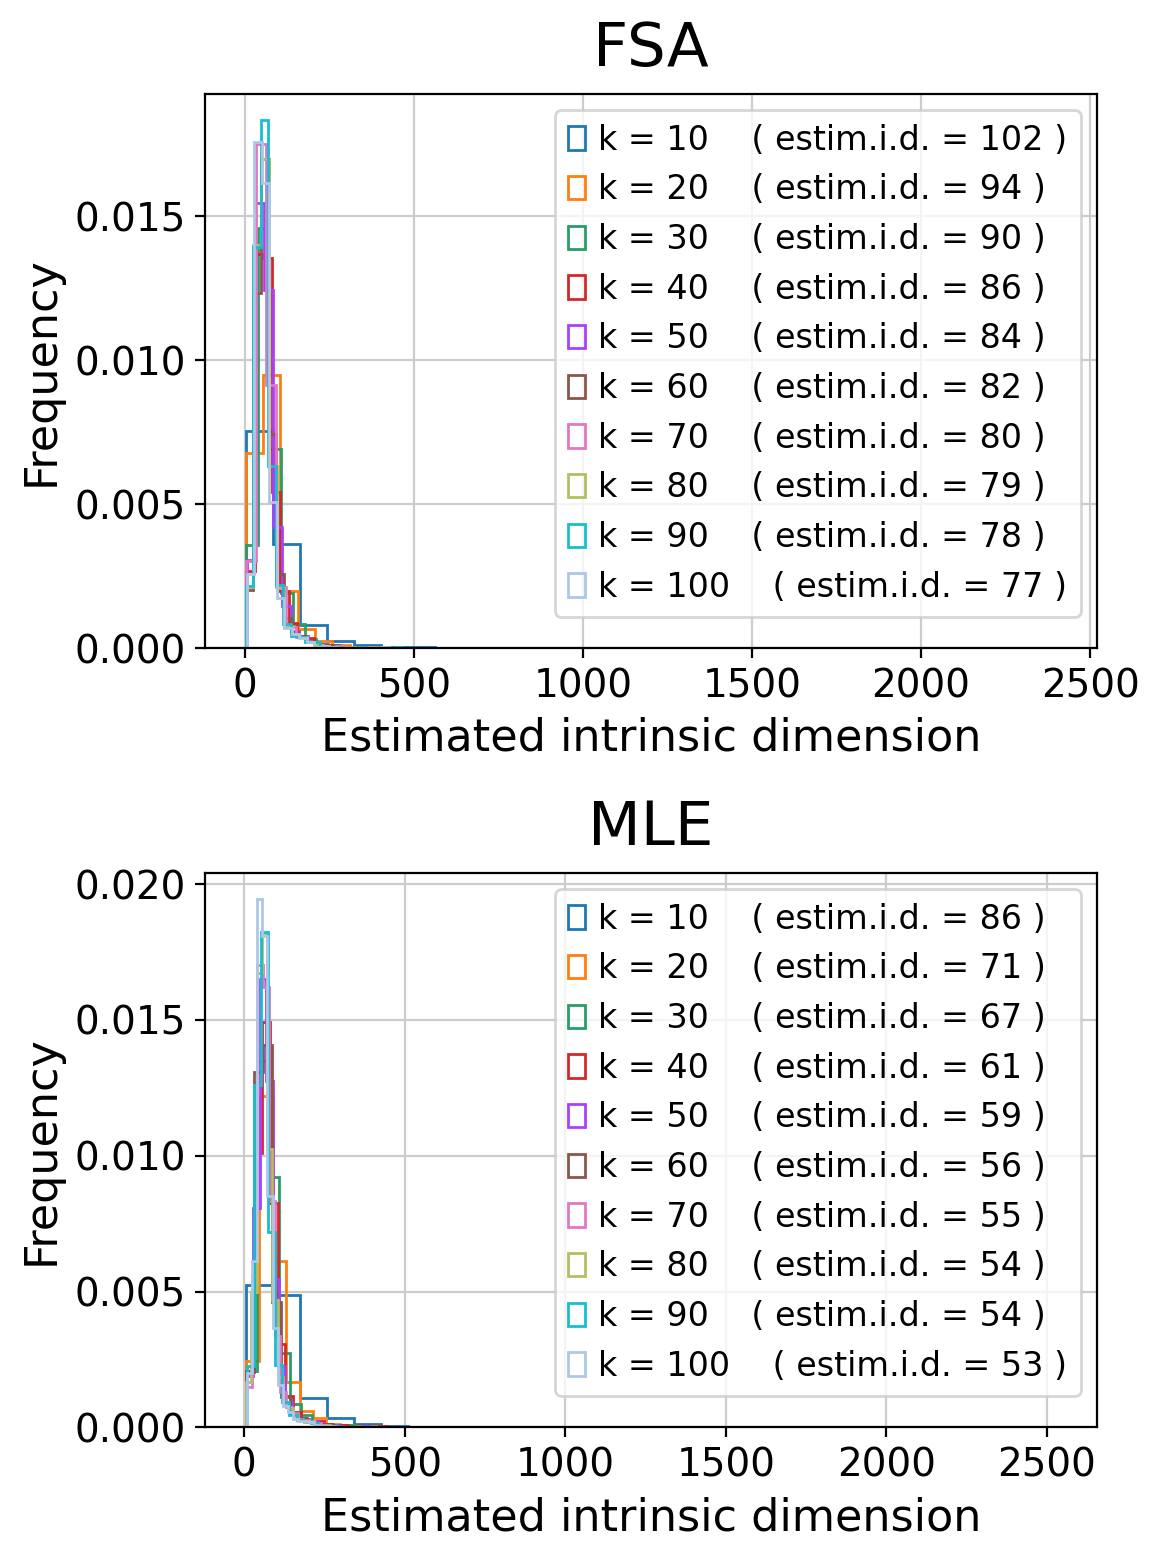

In [ ]:
from topo.tpgraph import IntrinsicDim

# Initialize the IntrinsicDim class with default parameters:
id_est = IntrinsicDim(
    methods=['fsa','mle'], # the methods we'll use
    k=range(10, 110, 10), # the number of k-neighbors to test
    backend='hnswlib',  # the approximate kNN backend to use
    metric='euclidean', # the distance metric to use
    n_jobs=-1, # the number of jobs to run in parallel
    plot=True, # whether to plot the results during fit()
    random_state=None) # the random state to use for colors

# Estimate the i.d.
id_est.fit(adata.X)

# Plot the results separately if `plot` was set to False
# id_est.plot_id()

As we can see, the global intrinsic dimensionality of this dataset is somewhere around 80. However, some cell populations can have IDs of almost 500! 

## Evaluating representations

TopoMetry provides a suite of **geometry-preservation metrics** that assess how well each scaffold or embedding captures the underlying data structure.  

The evaluation table includes:  
- **Topo preserve score (composite)**: an overall [0,1] measure.  
- **Rank diffusion correlation (RDC)**: correlation of diffusion distances.  
- **Neighbourhood preservation (D-kNP, trustworthiness, continuity)**: how well neighbours are retained.  
- **Spectral Procrustes (SP)** and **multiscale EMD (mD-EMD)**: fidelity of the spectral structure.  

We visualise results in a heatmap for a quick comparison across embeddings.  


In [ ]:
# Evaluate all embeddings/scaffolds living in adata.obsm against tg.base_kernel.P
df_eval = evaluate_representations(
    adata, tg,
    return_df=True,
    print_results=True,
    plot_results=True,
    plot_path=None,   # set path if you want a PNG saved
)
df_eval


## Tuning projections with `tg.project()`

Beyond the defaults, we can compute new projections directly from the `TopOGraph` object.  
For example, we can:  
- Increase the number of iterations in MAP optimisation.  
- Switch between msDM and DM scaffolds.  
- Try different layout methods such as PaCMAP.  

New projections can be stored in `adata.obsm` and re-evaluated with the same metrics.  
This allows iterative tweaking and direct comparison across multiple embeddings.  


Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!


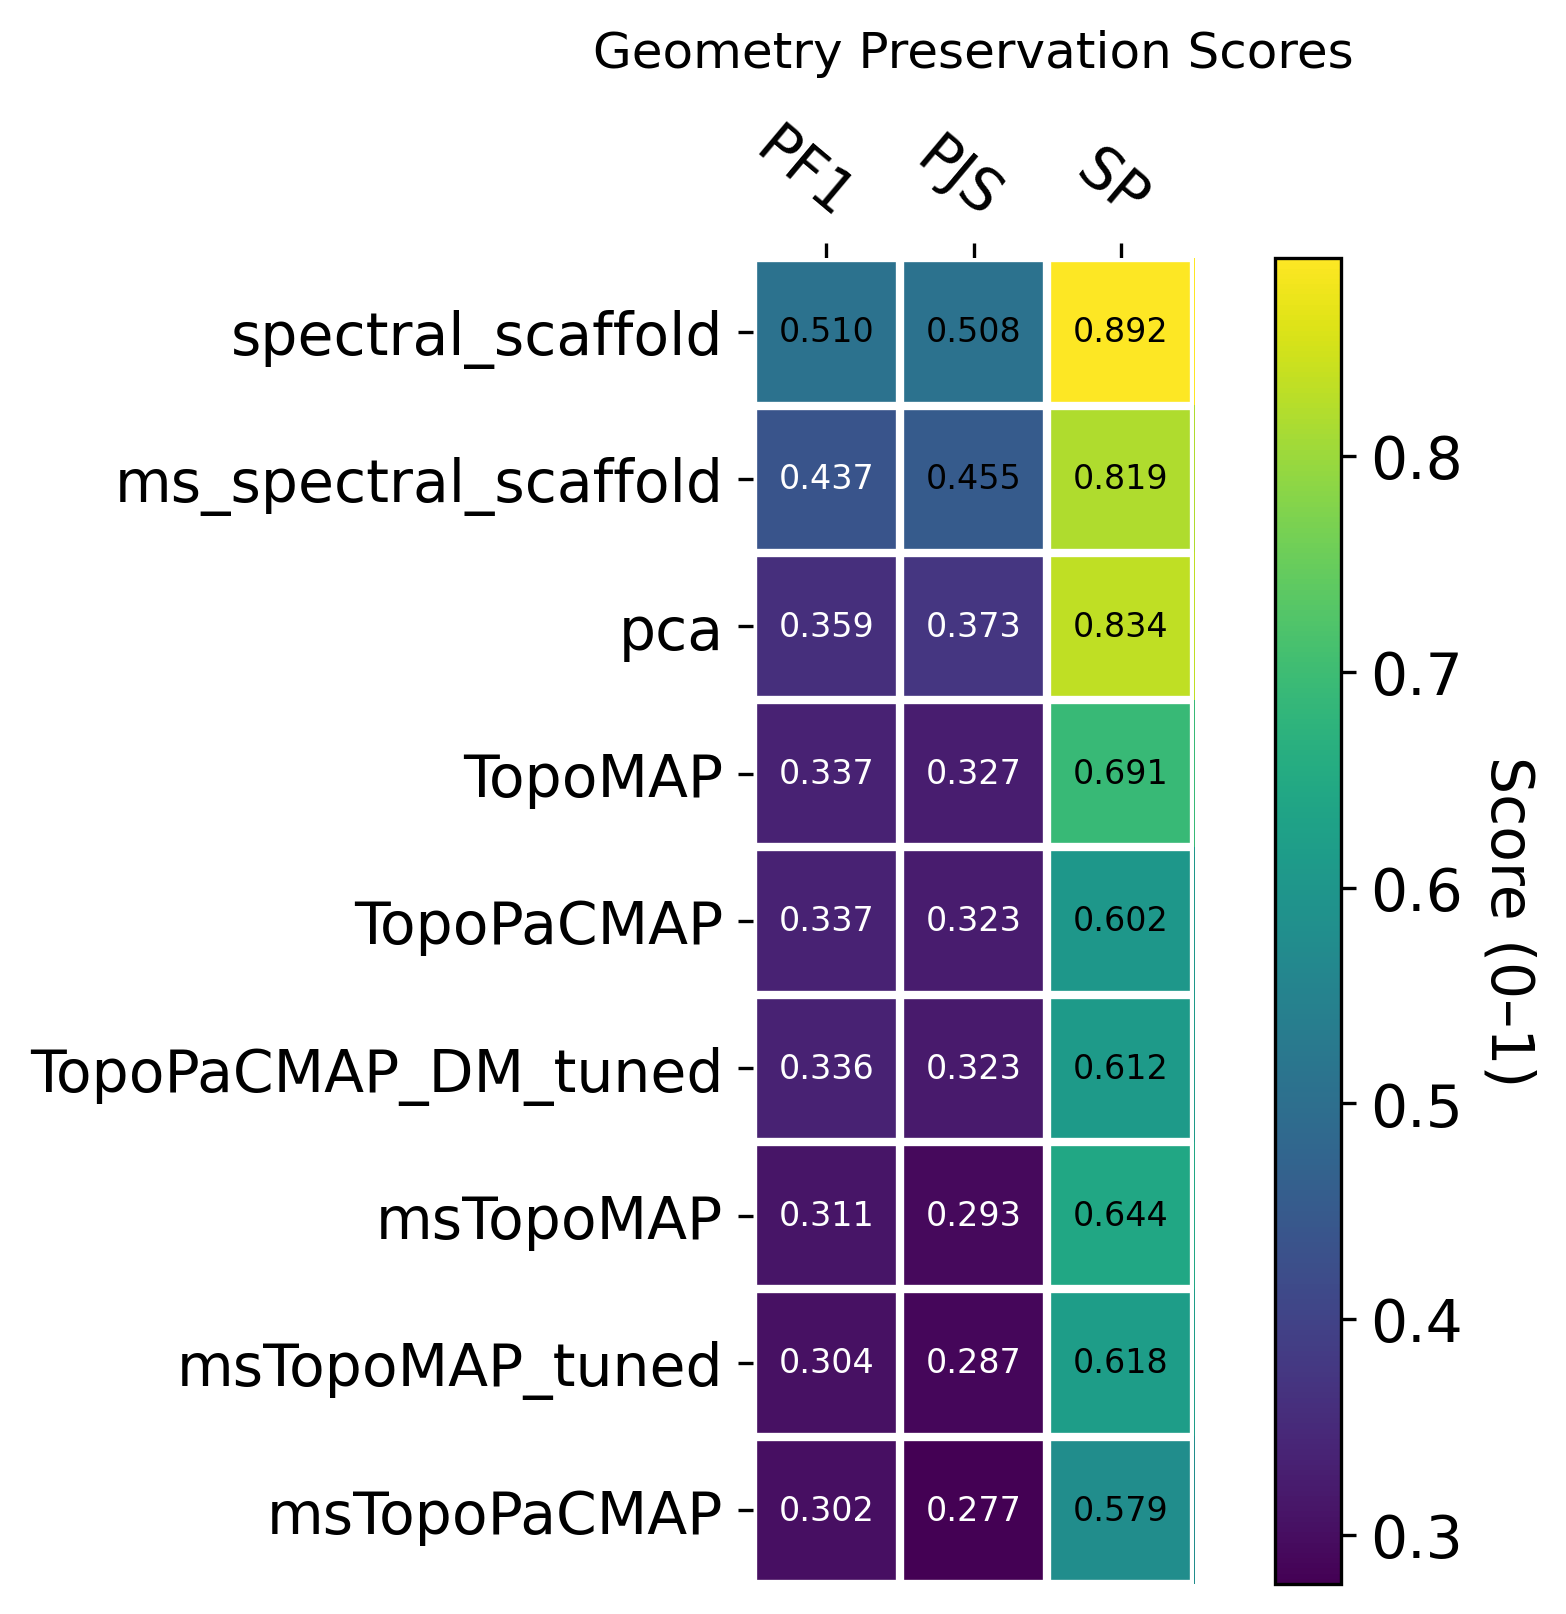

,representation,PF1,PJS,SP
0,spectral_scaffold,0.509851,0.507750,0.891793
1,ms_spectral_scaffold,0.436502,0.454728,0.819313
2,pca,0.359101,0.373368,0.833838
3,TopoMAP,0.336887,0.326770,0.690743
4,TopoPaCMAP,0.336800,0.323397,0.601683
5,TopoPaCMAP_DM_tuned,0.336240,0.322740,0.611564
6,msTopoMAP,0.310901,0.293244,0.644465
7,msTopoMAP_tuned,0.304252,0.286968,0.618448
8,msTopoPaCMAP,0.301565,0.277149,0.578990


In [ ]:
# Try a different MAP run (e.g., more iters; multiscale vs DM)
Y_ms_map = tg.project(
    projection_method="MAP",
    multiscale=True,
    num_iters=800,
    n_components=2,
    save_every=None,   # no checkpoints here
)
adata.obsm["X_msTopoMAP_tuned"] = Y_ms_map

# Try PaCMAP on DM scaffold
Y_dm_pac = tg.project(
    projection_method="PaCMAP",
    multiscale=False,
    n_components=2,
    num_iters=150,
)
adata.obsm["X_TopoPaCMAP_DM_tuned"] = Y_dm_pac

# Re-evaluate
df_eval2 = tp.sc.evaluate_representations(adata, tg, return_df=True, plot_results=True)
df_eval2


## Step 6 — Visualising MAP optimisation

MAP (Multiscale Affinity Preserving) optimisation is iterative. TopoMetry can **record intermediate snapshots** during training and combine them into an animated GIF.  

This animation reveals how the embedding stabilises over epochs:  
- Early frames capture rough global structure.  
- Later frames refine local neighbourhoods.  

Such visualisations help build intuition for the optimisation process and allow diagnosis of potential instabilities.  


In [ ]:
# Produces and returns GIF path; colors by a column or gene name
gif_path = tp.sc.visualize_optimization(
    adata, tg,
    groupby="topo_clusters",   # or a gene in adata.var_names
    num_iters=600,
    save_every=10,
    multiscale=True,
    fps=20,
    point_size=3.0,
    dpi=120,
    filename=None,             # auto-name if None
)
gif_path


'msTopoMAP_training_1758082405.gif'

## Step 8 — Visualising intrinsic dimensionality and spectral selectivity on embeddings

The embeddings themselves can be coloured by structural diagnostics:  
- **Intrinsic dimensionality values**: show which regions are geometrically complex (high ID) or simple (low ID).  
- **Spectral selectivity scores**: measure how strongly cells are aligned with individual diffusion axes.  

These overlays provide an intuitive, spatial view of which populations are topologically stable versus which are flexible or transitional.  


In [ ]:
# a) Intrinsic dimensionalities (pick low/high-k if present)
id_cols = [c for c in adata.obs.columns if c.startswith(("id_fsa_k","id_mle_k"))][:4] or ["spectral_radius"]
sc.pl.embedding(adata, basis="msTopoMAP", color=id_cols, wspace=0.25, cmap="viridis", show=True)

# b) Spectral selectivity summaries (computed inside run_topometry_analysis)
ss_cols = ["spectral_EAS","spectral_RayScore","spectral_LAC","spectral_axis"]
avail = [c for c in ss_cols if c in adata.obs.columns]
if avail:
    sc.pl.embedding(adata, basis="msTopoMAP", color=avail, wspace=0.25, show=True)


## Step 9 — Signal filtering (diffusion smoothing)

TopoMetry can propagate signals across the scaffold graph, effectively smoothing noisy measurements.  

This is demonstrated by simulating a “disease state” label with added noise, then filtering it through the diffusion operator.  
The filtered signal reduces noise while preserving population-level structure.  

This operation is a general tool: any continuous or categorical signal (e.g. gene scores, metadata) can be smoothed in this way.  


In [ ]:
# Simulate a noisy categorical signal and smooth it with P^t on msZ
from scipy.sparse import issparse

P = adata.obsp.get("topometry_connectivities_ms", None)
assert P is not None, "msDM connectivities not found."

rng = np.random.default_rng(7)
# Example: choose a cluster as 'diseased'
cl = adata.obs["topo_clusters"].astype(str)
mask = cl.isin(cl.cat.categories[:max(1, len(cl.cat.categories)//4)])
signal = mask.astype(float).values
noisy = np.clip(signal + 0.75 * rng.standard_normal(adata.n_obs), 0, 1)

t = 4
flt = noisy.copy()
for _ in range(t):
    flt = P @ flt

adata.obs["_sig_raw"] = noisy
adata.obs["_sig_flt"] = np.asarray(flt).ravel()
sc.pl.embedding(adata, basis="msTopoMAP", color=["_sig_raw","_sig_flt"], cmap="coolwarm", wspace=0.25, show=True)

# cleanup (optional)
for k in ["_sig_raw","_sig_flt"]:
    del adata.obs[k]


## Step 10 — Imputation and QC

TopoMetry also supports **expression imputation**, diffusing gene expression across the scaffold.  

A QC routine selects the best diffusion time (`t`) by comparing correlations with null distributions.  
The chosen imputed matrix is stored in `adata.layers['topo_imputation']`.  

Plots can then show genes on the original vs imputed data, illustrating how dropout artefacts are reduced and gradients become clearer.  

**Important:** imputation is for **visualisation/QC** only, not for differential expression or downstream quantification.  


In [ ]:
# Choose best t via null-based QC; stores best result in adata.layers['topo_imputation']
impute_adata(
    adata, tg,
    layer="X",           # or "counts" / "scaled"
    raw=False,           # set True to impute adata.raw
    which="msZ",
    impute_t_grid=(1,2,4,8,16),
    null_K=1000,
    heatmap_top_genes=100,
)

# QC line plot
iqc = adata.uns.get("imputation_qc", {})
df_stats = iqc.get("stats", None)
if isinstance(df_stats, pd.DataFrame) and not df_stats.empty:
    ax = df_stats.plot(x="t", y=["score_mean_abs_corr","null_mean"], style=["-o","--o"], figsize=(5,3), dpi=120)
    ax.set_ylabel("mean |corr|"); ax.set_xlabel("t")
    best_t = iqc.get("best_t", None)
    if best_t is not None:
        ax.axvline(best_t, color="k", ls=":", lw=1)
    plt.show()

# Plot a few marker genes across layers
genes = adata.var_names[:4].tolist()
for layer in ["X", "topo_imputation"]:
    if layer == "X":
        sc.pl.embedding(adata, basis="msTopoMAP", color=genes, layer=None, cmap="inferno", wspace=0.25, show=True)
    else:
        sc.pl.embedding(adata, basis="msTopoMAP", color=genes, layer="topo_imputation", cmap="inferno", wspace=0.25, show=True)


## Step 11 — Pseudotime estimation

TopoMetry supports diffusion-based pseudotime analysis.  
By selecting a starting cluster, the algorithm computes diffusion pseudotime values across the msDM scaffold.  

The result is stored in `adata.obs['topo_pseudotime']` and can be visualised on any embedding.  
This enables reconstruction of continuous trajectories such as differentiation paths or response gradients.  


In [ ]:
# Pick a starting cluster (string must match a label in adata.obs['topo_clusters'])
start = adata.obs["topo_clusters"].cat.categories[0]
info = pseudotime_analysis(
    adata, tg,
    starting_cluster=start,
    groupby="topo_clusters",
    lineage_mask=None,        # or a boolean mask aligned to tg (see docstring)
    random_state=42,
)
print(info)

# Visualize on TopoMAP
sc.pl.embedding(adata, basis="msTopoMAP", color="topo_pseudotime", cmap="viridis", show=True)


## Step 12 — Riemannian diagnostics (optional)

Finally, TopOMetry provides Riemannian diagnostics to quantify **distortions in the local metric** when projecting data.  

For each embedding, we can visualise contraction (blue) and expansion (red) relative to the scaffold geometry.  
This helps detect embeddings that stretch or compress certain populations more than others, guiding users towards faithful layouts.  


In [ ]:
# Runs on *all* 2D embeddings in adata.obsm; writes per-embedding scalars to adata.obs
riemann_diagnostics(
    adata, tg,
    center="median",
    diffusion_t=8,
    diffusion_op="X",
    normalize="symmetric",
    clip_percentile=2.0,
)

# Example: show the deformation scalar on msTopoMAP
col = "metric_deformation__X_msTopoMAP"
if col in adata.obs:
    sc.pl.embedding(adata, basis="msTopoMAP", color=col, cmap="bwr", show=True)
